<a href="https://colab.research.google.com/github/y7chinmay/rice-type-classification-knn/blob/main/Rice_Grain_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
!unzip Rice_Images.zip

Archive:  Rice_Images.zip
   creating: Rice_Images/
   creating: Rice_Images/BASMATI100/
  inflating: Rice_Images/BASMATI100/Basmati (1).jpg  
  inflating: Rice_Images/BASMATI100/basmati (10).jpg  
  inflating: Rice_Images/BASMATI100/basmati (100).jpg  
  inflating: Rice_Images/BASMATI100/basmati (101).jpg  
  inflating: Rice_Images/BASMATI100/basmati (11).jpg  
  inflating: Rice_Images/BASMATI100/basmati (12).jpg  
  inflating: Rice_Images/BASMATI100/basmati (13).jpg  
  inflating: Rice_Images/BASMATI100/basmati (14).jpg  
  inflating: Rice_Images/BASMATI100/basmati (15).jpg  
  inflating: Rice_Images/BASMATI100/basmati (16).jpg  
  inflating: Rice_Images/BASMATI100/basmati (17).jpg  
  inflating: Rice_Images/BASMATI100/basmati (18).jpg  
  inflating: Rice_Images/BASMATI100/basmati (19).jpg  
  inflating: Rice_Images/BASMATI100/basmati (20).jpg  
  inflating: Rice_Images/BASMATI100/basmati (21).jpg  
  inflating: Rice_Images/BASMATI100/basmati (22).jpg  
  inflating: Rice_Images/BASMA

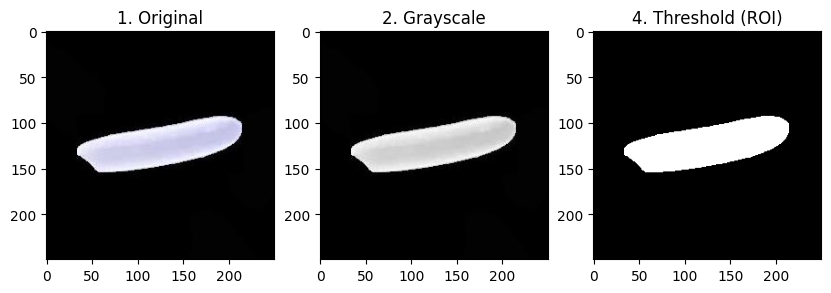

In [4]:
import cv2
import matplotlib.pyplot as plt

 # Changed to an existing file and corrected directory structure

image_basmati = cv2.imread('/content/Rice_Images/BASMATI100/basmati (49).jpg')

if image_basmati is None:
    print("Error: Image not found or could not be loaded. Please check the path and filename.")
else:

    gray = cv2.cvtColor(image_basmati, cv2.COLOR_BGR2GRAY)


    blurred = cv2.GaussianBlur(gray, (5, 5), 0)


    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    #  Displaying the results to check your work
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 3, 1)
    plt.title("1. Original")
    plt.imshow(cv2.cvtColor(image_basmati, cv2.COLOR_BGR2RGB))

    plt.subplot(1, 3, 2)
    plt.title("2. Grayscale")
    plt.imshow(gray, cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title("4. Threshold (ROI)")
    plt.imshow(thresh, cmap='gray')

    plt.show()

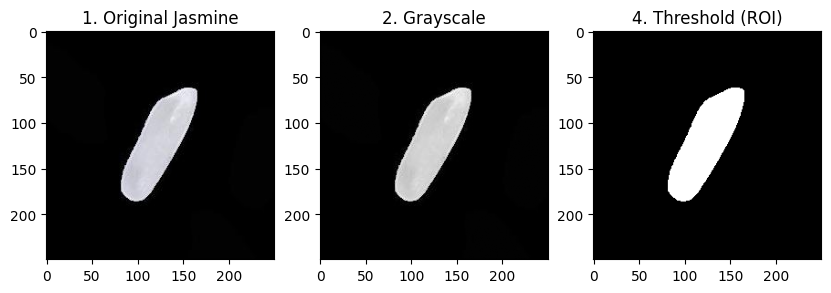

In [5]:
import cv2
import matplotlib.pyplot as plt


img_jasmine = cv2.imread('/content/Rice_Images/JASMINE100/Jasmine (101).jpg')

if img_jasmine is None:
    print("Error: Image not found or could not be loaded. Please check the path and filename.")
else:
    gray_jasmine = cv2.cvtColor(img_jasmine, cv2.COLOR_BGR2GRAY)


    blurred_jasmine = cv2.GaussianBlur(gray_jasmine, (5, 5), 0)


    _, thresh_jasmine = cv2.threshold(blurred_jasmine, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


    plt.figure(figsize=(10, 5))

    plt.subplot(1, 3, 1)
    plt.title("1. Original Jasmine")
    plt.imshow(cv2.cvtColor(img_jasmine, cv2.COLOR_BGR2RGB))

    plt.subplot(1, 3, 2)
    plt.title("2. Grayscale")
    plt.imshow(gray_jasmine, cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title("4. Threshold (ROI)")
    plt.imshow(thresh_jasmine, cmap='gray')

    plt.show()

In [7]:
import cv2
import numpy as np
import pandas as pd
import os


classes = ['BASMATI100', 'JASMINE100']
all_features = []

for label in classes:
    path = f'/content/Rice_Images/{label}'

    images = os.listdir(path)[:100]

    for img_name in images:
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path)
        if img is None: continue


        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (5,5), 0)
        ret, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contour in contours:
            area = cv2.contourArea(contour)

            if area > 500:
                perimeter = cv2.arcLength(contour, True)

                compactness = (perimeter**2) / (4 * np.pi * area) if area > 0 else 0
                if len(contour) >= 5:
                    (x, y), (MA, ma), angle = cv2.fitEllipse(contour)
                    eccentricity = np.sqrt(1 - (MA / ma)**2)
                else:
                    eccentricity = 0


                all_features.append({
                    'area': area,
                    'perimeter': perimeter,
                    'compactness': compactness,
                    'eccentricity': eccentricity,
                    'label': label
                })


features_df = pd.DataFrame(all_features)


display(features_df.head())


features_df.to_csv('rice_features.csv', index=False)
print("CSV file 'rice_features.csv' has been created successfully!")

,area,perimeter,compactness,eccentricity,label
0,6400.0,409.671135,2.086800,0.972489,BASMATI100
1,5626.5,429.178713,2.605123,0.984231,BASMATI100
2,5907.5,425.345233,2.437079,0.979211,BASMATI100
3,6925.5,431.570628,2.140143,0.976842,BASMATI100
4,9186.0,477.504614,1.975235,0.963415,BASMATI100


CSV file 'rice_features.csv' has been created successfully!


In [8]:

features_df['label_num'] = features_df['label'].map({'BASMATI100': 0, 'JASMINE100': 1})

In [9]:
from sklearn.model_selection import train_test_split


X = features_df[['area', 'perimeter', 'compactness', 'eccentricity']]
y = features_df['label_num']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 160
Testing samples: 40


In [10]:
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors=5)


knn.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


Overall Model Accuracy: 92.50%
------------------------------
Classification Report:
              precision    recall  f1-score   support

  BASMATI100       0.95      0.90      0.93        21
  JASMINE100       0.90      0.95      0.92        19

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.93        40



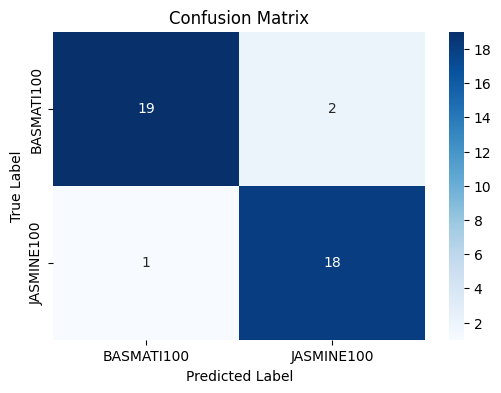

In [11]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


y_pred = knn.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['BASMATI100', 'JASMINE100']))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BASMATI100', 'JASMINE100'],
            yticklabels=['BASMATI100', 'JASMINE100'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

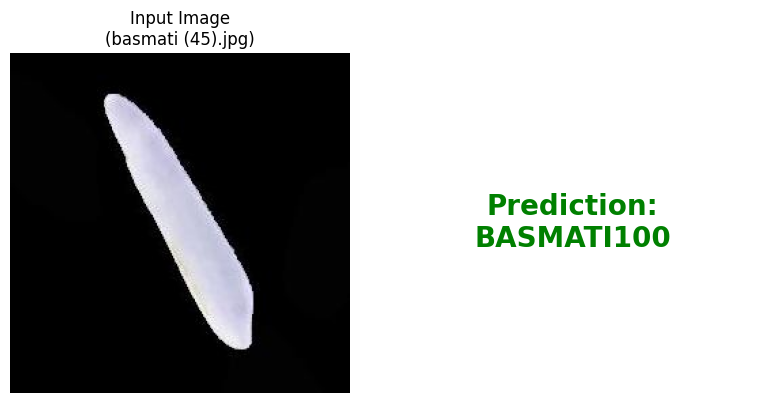

In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


test_img_path = '/content/Rice_Images/BASMATI100/basmati (45).jpg'

def predict_rice_type(img_path):

    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Test image not found or could not be loaded at {img_path}. Please check the path and filename.")
        return
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    compactness = (perimeter**2) / (4 * np.pi * area) if area > 0 else 0


    if len(cnt) >= 5:
        (x, y), (MA, ma), angle = cv2.fitEllipse(cnt)
        eccentricity = np.sqrt(1 - (MA / ma)**2) if ma != 0 else 0
    else:
        eccentricity = 0

    # Create a DataFrame for the sample features with correct column names
    sample_features = pd.DataFrame([[area, perimeter, compactness, eccentricity]],
                                     columns=['area', 'perimeter', 'compactness', 'eccentricity'])

    prediction = knn.predict(sample_features)
    result = 'BASMATI100' if prediction[0] == 0 else 'JASMINE100'


    plt.figure(figsize=(8, 4))


    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Input Image\n({img_path.split('/')[-1]})")
    plt.axis('off')


    plt.subplot(1, 2, 2)
    plt.text(0.5, 0.5, f"Prediction:\n{result}",
             fontsize=20, ha='center', va='center', color='green', weight='bold')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


predict_rice_type(test_img_path)